In [1]:
import os

# change directory one up 
os.chdir('..')

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_and_concat_shift_files(folder_path, prefix, column_name, pos=-1):
    """
    Load CSV files from folder_path that start with prefix, sort them based on the number
    at the end of the filename, add a column with that number, and concatenate all into a single DataFrame.
    
    Args:
        folder_path (str): Path to the folder containing the CSV files.
        prefix (str): Prefix of the files to include.
        column_name (str): Name of the new column to store the shift number.
        idx (int): Index of the parameter to shift (default: -1 for last parameter).

    Returns:
        pd.DataFrame: Concatenated DataFrame of all relevant CSVs with shift column added.
    """
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    # sort files by the number at the end
    shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[pos].replace('.csv','')))
    for idx, f in enumerate(shift_files):
        df = pd.read_csv(os.path.join(folder_path, f))
        df[column_name] = float(f.split('_')[-1].replace('.csv',''))
        if idx == 0:
            combined_df = df
        else:
            combined_df = pd.concat([combined_df, df])
    
    return combined_df

def load_and_concat_multi_shift_files(folder_path, prefix, column_name_relevance, column_name_idx):
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    print(shift_files)
    # sort files by the number at the end
    shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[-2].replace('.csv','')))
    shift_files = sorted(shift_files, key=lambda x: float(x.split('idx')[-1].replace('.csv','')))
    for idx, f in enumerate(shift_files):
        df = pd.read_csv(os.path.join(folder_path, f))
        df[column_name_relevance] = float(f.split('_')[-2].replace('.csv',''))
        df[column_name_idx] = int(f.split('idx')[-1].replace('.csv',''))
        if idx == 0:
            combined_df = df
        else:
            combined_df = pd.concat([combined_df, df])
    return combined_df# plot the relevance shift for each param idx, taking the mean shift of relevance compared to shift 0

def plot_mean_relevance_shift_box(multi_relevance_df, temperature):
    for idx in range(10):
        subset = multi_relevance_df[multi_relevance_df['param_idx'] == idx]
        baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        
        diff_df = pd.DataFrame()
        for shift in subset['relevance_shift'].unique():
            values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df[shift] = values - baseline  # element-wise difference
        
        plt.figure(figsize=(12, 6))
        diff_df.boxplot(grid=True)
        
        plt.xlabel('Relevance Parameter Shift')
        plt.ylabel('Difference in Relevance Compared to Shift 0')
        plt.title(f'Distribution of Element-wise Differences Across Parameter Shifts for Param Index {idx} and temperature {temperature}')
        plt.show()

# plot the plot as a line plot instead of boxplot, showing mean and std
def plot_mean_relevance_shift_grid(multi_relevance_df, temperature, sampler):
    fig, axes = plt.subplots(2, 5, figsize=(21, 9), sharey=True)
    axes = axes.flatten()

    all_means = []
    all_stds = []

    for idx in range(10):
        ax = axes[idx]
        subset = multi_relevance_df[multi_relevance_df['param_idx'] == idx]
        baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        
        diff_df = pd.DataFrame()
        for shift in subset['relevance_shift'].unique():
            values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df[shift] = values - baseline  # element-wise difference
        
        means = diff_df.mean()
        stds = diff_df.std()
        
        all_means.extend(means.values)
        all_stds.extend(stds.values)

        ax.plot(means.index, means.values, marker='o', label='Mean Difference', linewidth=2)
        ax.fill_between(means.index, means - stds, means + stds, 
                        color='b', alpha=0.2, label='±1 Std Dev')
        
        ax.set_title(f'Param {idx}', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if idx % 5 == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=14)
        if idx >= 5:
            ax.set_xlabel('Relevance Shift', fontsize=14)

    # Adjust y-limits globally (zoom in with 10% margin)
    ymin = min(all_means) - max(all_stds) * 1.1
    ymax = max(all_means) + max(all_stds) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    # Global title
    # fig.suptitle(f'Mean Element-wise Differences Across Parameter Shifts (temperature={temperature}, sampler={sampler})',
    #              fontsize=20, y=1.02)

    # Put legend below all subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=14, ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

def plot_mean_relevance_shift_all(multi_relevance_dfs, temperatures, plot_title):
    """
    Plot mean Δ relevance vs shift for each param_idx in a grid,
    overlaying results for multiple temperatures.

    Args:
        multi_relevance_dfs (list[pd.DataFrame]): list of DataFrames, one per temperature
        temperatures (list): list of temperature values (same order as dfs)
    """
    # Determine unique parameter indices dynamically
    all_param_indices = sorted(multi_relevance_dfs[0]['param_idx'].unique())
    n_params = len(all_param_indices)

    # Compute grid layout (max 5 columns)
    n_cols = min(5, n_params)
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows), sharey=True)
    axes = np.array(axes).flatten()



    all_means, all_stds = [], []

    for i, idx in enumerate(all_param_indices):
        ax = axes[i]

        for df, temp in zip(multi_relevance_dfs, temperatures):
            subset = df[df['param_idx'] == idx]
            if subset.empty:
                continue

            # Compute baseline at shift = 0
            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)

            diff_df = pd.DataFrame()
            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()
            stds = diff_df.std()

            # shaded confidence area
            ax.fill_between(means.index, means - stds, means + stds, alpha=0.2, zorder=1)
            # line plot
            ax.plot(means.index, means.values, marker='o', linewidth=2,
                    label=f'T={temp}', zorder=2)

            all_means.extend(means.values)
            all_stds.extend(stds.values)

        ax.set_title(f'Param {idx}', fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if i % n_cols == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=12)
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel('Relevance Shift', fontsize=12)

    # Remove unused subplots (if any)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Consistent y-limits
    if all_means and all_stds:
        ymin = min(all_means) - max(all_stds) * 1.1
        ymax = max(all_means) + max(all_stds) * 1.1
        for ax in axes[:n_params]:
            ax.set_ylim(ymin, ymax)

    # Global title
    # fig.suptitle('Mean Element-wise Δ Relevance Across Parameter Shifts (All Temperatures)',
    #              fontsize=18, y=1.02)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', fontsize=12,
                   ncol=min(len(temperatures), 5), frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(plot_title, bbox_inches='tight')
    plt.show()

def plot_performance_grid_all_temps(multi_performance_dfs, temperatures, plot_title, metric='ndcg@10'):
    """
    Plot metric vs Relevance Shift for each param_idx in a grid,
    overlaying results for multiple temperatures.

    Args:
        multi_performance_dfs (list[pd.DataFrame]): list of DataFrames, one per temperature
        temperatures (list): list of temperature values (same order as dfs)
        metric (str): performance metric to plot (default 'ndcg@10')
    """
    # Determine unique param indices from the first df
    all_param_indices = sorted(multi_performance_dfs[0]['param_idx'].unique())
    n_params = len(all_param_indices)

    # Compute grid size (2 rows if >5 params, else 1 row)
    n_cols = min(5, n_params)
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows), sharey=True)
    axes = np.array(axes).flatten()  # Flatten in case of 2D axes

    for i, idx in enumerate(all_param_indices):
        ax = axes[i]
        for df, temp in zip(multi_performance_dfs, temperatures):
            subset = df[df['param_idx'] == idx]
            if subset.empty:
                continue
            ax.plot(subset['relevance_shift'], subset[metric], marker='o', linewidth=2, label=f'T={temp}')

        ax.set_title(f'Param {idx}', fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if i % n_cols == 0:
            ax.set_ylabel(metric, fontsize=12)
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel('Relevance Shift', fontsize=12)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Global title
    # fig.suptitle(f'{metric.upper()} vs Relevance Parameter Shift Across Temperatures',
    #              fontsize=18, y=1.02)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', fontsize=12,
                   ncol=len(temperatures), frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    # save plot to file
    plt.savefig(plot_title, bbox_inches='tight')
    plt.show()

['relevance_param_shift_1.0_idx1.csv', 'relevance_param_shift_-3.0_idx1.csv', 'relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_1.0_idx2.csv', 'relevance_param_shift_-3.0_idx2.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_3.0_idx1.csv', 'relevance_param_shift_-1.0_idx1.csv', 'relevance_param_shift_3.0_idx2.csv', 'relevance_param_shift_-1.0_idx2.csv', 'relevance_param_shift_0.0_idx1.csv', 'relevance_param_shift_-2.0_idx1.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_0.0_idx2.csv', 'relevance_param_shift_-2.0_idx2.csv', 'relevance_param_shift_2.0_idx0.csv', 'relevance_param_shift_2.0_idx1.csv', 'relevance_param_shift_2.0_idx2.csv']
['relevance_param_shift_1.0_idx1.csv', 'relevance_param_shift_-3.0_idx1.csv', 'relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_1.0_idx2.csv',

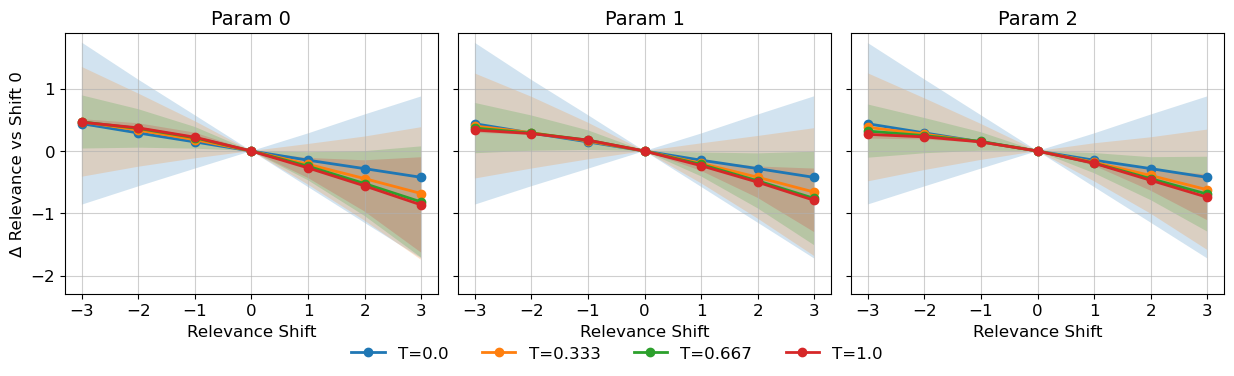

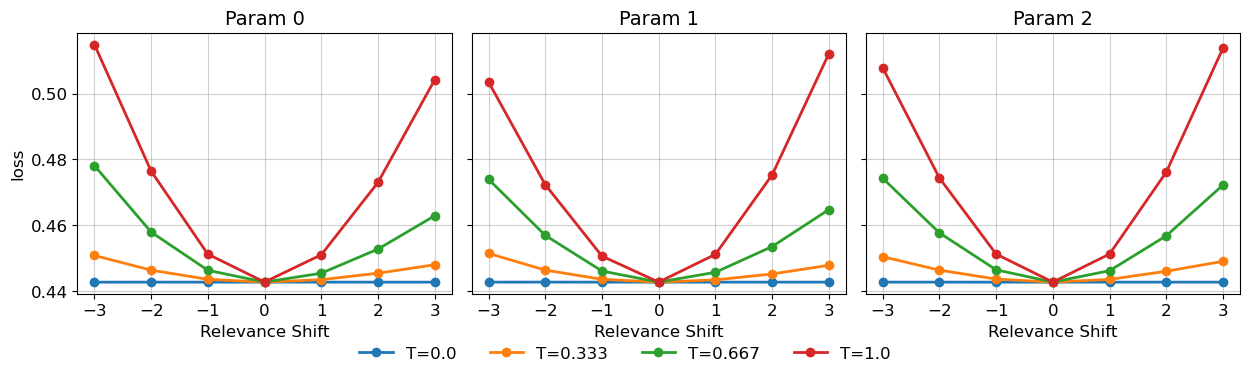

In [11]:
prefix = 'relevance_param_shift_'
folder_path_test = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=linear,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=linear,relevance_tower=linear'
folder_path_test_0333 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=linear,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=linear,relevance_tower=linear'
folder_path_test_0667 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=linear,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=linear,relevance_tower=linear'
folder_path_test_1 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=linear,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=linear,relevance_tower=linear'

multi_relevance_df_test = load_and_concat_multi_shift_files(folder_path_test, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333 = load_and_concat_multi_shift_files(folder_path_test_0333, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667 = load_and_concat_multi_shift_files(folder_path_test_0667, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1 = load_and_concat_multi_shift_files(folder_path_test_1, prefix, 'relevance_shift', 'param_idx')

# get performance df
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

multi_performance_df_test = load_and_concat_multi_shift_files(folder_path_test, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333 = load_and_concat_multi_shift_files(folder_path_test_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667 = load_and_concat_multi_shift_files(folder_path_test_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1 = load_and_concat_multi_shift_files(folder_path_test_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')

plot_mean_relevance_shift_all([multi_relevance_df_test, multi_relevance_df_test_0333, multi_relevance_df_test_0667, multi_relevance_df_test_1], [0.0, 0.333, 0.667, 1.0], 'notebooks/plots/linear_model_mean_relevance_shift_all_temps.pdf')
plot_performance_grid_all_temps([multi_performance_df_test, multi_performance_df_test_0333, multi_performance_df_test_0667, multi_performance_df_test_1], [0.0, 0.333, 0.667, 1.0],'notebooks/plots/linear_model_performance_grid_all_temps.pdf', 'loss')

['relevance_param_shift_1.0_idx1.csv', 'relevance_param_shift_-3.0_idx1.csv', 'relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_1.0_idx2.csv', 'relevance_param_shift_-3.0_idx2.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_3.0_idx1.csv', 'relevance_param_shift_-1.0_idx1.csv', 'relevance_param_shift_3.0_idx2.csv', 'relevance_param_shift_-1.0_idx2.csv', 'relevance_param_shift_0.0_idx1.csv', 'relevance_param_shift_-2.0_idx1.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_0.0_idx2.csv', 'relevance_param_shift_-2.0_idx2.csv', 'relevance_param_shift_2.0_idx0.csv', 'relevance_param_shift_2.0_idx1.csv', 'relevance_param_shift_2.0_idx2.csv']
['relevance_param_shift_1.0_idx1.csv', 'relevance_param_shift_-3.0_idx1.csv', 'relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_1.0_idx2.csv',

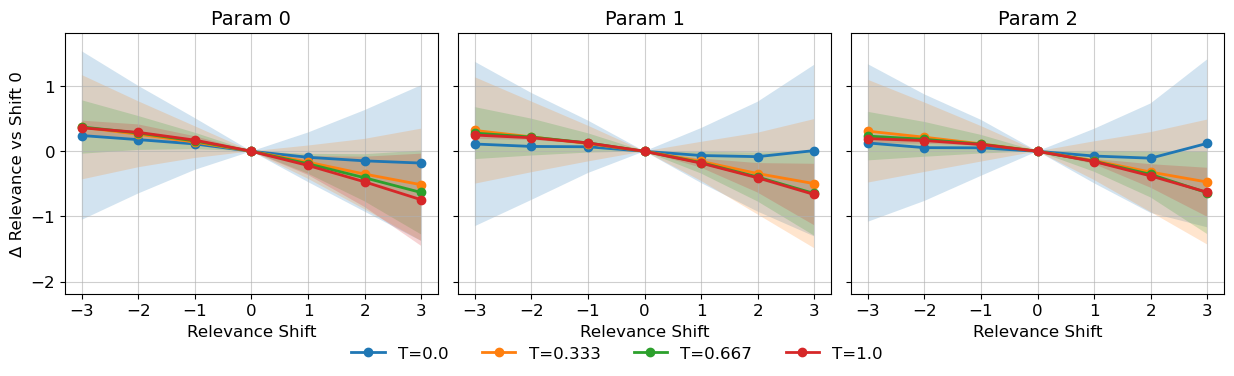

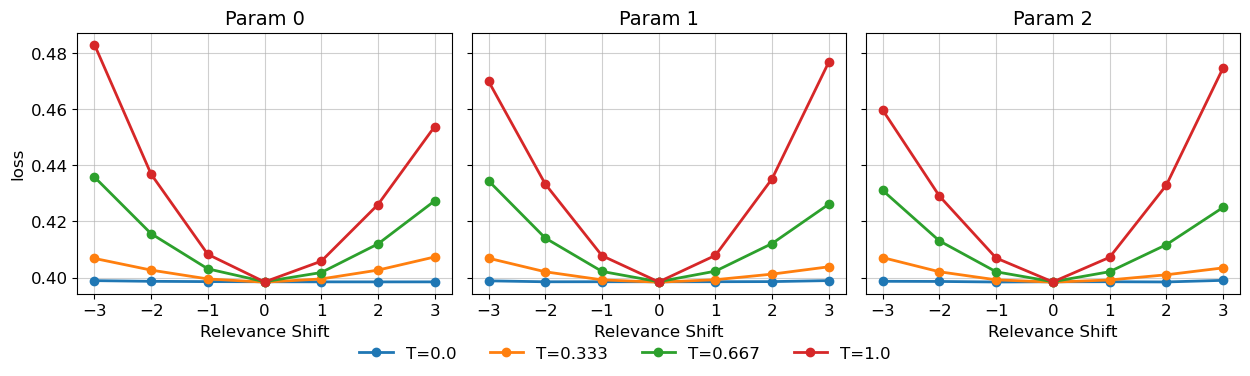

In [12]:
folder_path_test_deep = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_0333 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_0667 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_1 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep'
multi_relevance_df_test_deep = load_and_concat_multi_shift_files(folder_path_test_deep, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_0333 = load_and_concat_multi_shift_files(folder_path_test_deep_0333, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_0667 = load_and_concat_multi_shift_files(folder_path_test_deep_0667, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_1 = load_and_concat_multi_shift_files(folder_path_test_deep_1, prefix, 'relevance_shift', 'param_idx')
# get performance df
multi_performance_df_test_deep = load_and_concat_multi_shift_files(folder_path_test_deep, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_0333 = load_and_concat_multi_shift_files(folder_path_test_deep_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_0667 = load_and_concat_multi_shift_files(folder_path_test_deep_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_1 = load_and_concat_multi_shift_files(folder_path_test_deep_1, prefix_performance_clicks, 'relevance_shift', 'param_idx') 

plot_mean_relevance_shift_all([multi_relevance_df_test_deep, multi_relevance_df_test_deep_0333, multi_relevance_df_test_deep_0667, multi_relevance_df_test_deep_1], [0.0, 0.333, 0.667, 1.0], 'notebooks/plots/deep_model_mean_relevance_shift_all_temps.pdf')
plot_performance_grid_all_temps([multi_performance_df_test_deep, multi_performance_df_test_deep_0333, multi_performance_df_test_deep_0667, multi_performance_df_test_deep_1], [0.0, 0.333, 0.667, 1.0], 'notebooks/plots/deep_model_performance_grid_all_temps.pdf', 'loss')